<a href="https://colab.research.google.com/github/Maniganiga404/AML/blob/main/AMLlab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
#Lab5
#take dataset try using decision tree observe overfitting the post pruning and pre pruning and observe tree again

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


In [12]:
# Load data
# 1. LOAD DATASET
# ==========================================

data = load_breast_cancer(as_frame=True)

X = data.data
y = data.target

print("HEAD")
display(data.frame.head())

print("\nSHAPE")
print(data.frame.shape)

print("\nMISSING VALUES")
print(data.frame.isnull().sum().sum())


HEAD


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



SHAPE
(569, 31)

MISSING VALUES
0


In [13]:
# Split data
# 2. SPLIT DATA
# ==========================================

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Split training data again
# 80% actual training, 20% validation
X_train_prune, X_val, y_train_prune, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)



In [14]:
# 3. UNPRUNED DECISION TREE
# ==========================================

unpruned_tree = DecisionTreeClassifier(
    random_state=42
)

unpruned_tree.fit(X_train_prune, y_train_prune)

train_pred = unpruned_tree.predict(X_train_prune)
val_pred = unpruned_tree.predict(X_val)

print("\nUNPRUNED TREE")

print("Training Accuracy:",
      accuracy_score(y_train_prune, train_pred))

print("Validation Accuracy:",
      accuracy_score(y_val, val_pred))

print("Depth:",
      unpruned_tree.get_depth())

print("Leaves:",
      unpruned_tree.get_n_leaves())



UNPRUNED TREE
Training Accuracy: 1.0
Validation Accuracy: 0.945054945054945
Depth: 6
Leaves: 16


In [15]:
# 4. FIND POSSIBLE PRUNING VALUES
# ==========================================

path = unpruned_tree.cost_complexity_pruning_path(
    X_train_prune,
    y_train_prune
)

alphas = path.ccp_alphas

print("\nNUMBER OF ALPHAS:", len(alphas))




NUMBER OF ALPHAS: 11


In [16]:
# 5. TRY DIFFERENT ALPHA VALUES
# ==========================================

results = []

for alpha in alphas:

    tree = DecisionTreeClassifier(
        ccp_alpha=alpha,
        random_state=42
    )

    tree.fit(X_train_prune, y_train_prune)

    train_pred = tree.predict(X_train_prune)
    val_pred = tree.predict(X_val)

    results.append({
        "ALPHA": alpha,
        "DEPTH": tree.get_depth(),
        "LEAVES": tree.get_n_leaves(),

        "TRAIN_ACCURACY":
            accuracy_score(y_train_prune, train_pred),

        "VALIDATION_ACCURACY":
            accuracy_score(y_val, val_pred)
    })

# Convert results into DataFrame
results_df = pd.DataFrame(results)

print("\nPRUNING RESULTS")
display(results_df)


PRUNING RESULTS


,ALPHA,DEPTH,LEAVES,TRAIN_ACCURACY,VALIDATION_ACCURACY
0,0.000000,6,16,1.000000,0.945055
1,0.002633,6,14,0.997253,0.967033
2,0.002724,5,12,0.994505,0.967033
3,0.002733,5,10,0.991758,0.956044
4,0.005072,5,9,0.989011,0.945055
5,0.005310,5,7,0.983516,0.945055
6,0.008242,4,6,0.978022,0.945055
7,0.011720,2,4,0.967033,0.945055
8,0.020205,2,3,0.956044,0.945055
9,0.053285,1,2,0.925824,0.890110


In [18]:
# 6. FIND BEST ALPHA
# ==========================================

best_row = results_df.loc[
    results_df["VALIDATION_ACCURACY"].idxmax()
]

best_alpha = best_row["ALPHA"]

print("\nBEST ALPHA:", best_alpha)

print("BEST VALIDATION ACCURACY:",
      best_row["VALIDATION_ACCURACY"])




BEST ALPHA: 0.0026327838827838843
BEST VALIDATION ACCURACY: 0.967032967032967


In [19]:
# 7. BUILD FINAL PRUNED TREE
# ==========================================

final_tree = DecisionTreeClassifier(
    ccp_alpha=best_alpha,
    random_state=42
)

# Train using the complete training data
final_tree.fit(X_train, y_train)

final_pred = final_tree.predict(X_test)

In [20]:
# 8. FINAL TEST RESULTS
# ==========================================

print("\nFINAL PRUNED TREE")

print("Test Accuracy:",
      accuracy_score(y_test, final_pred))

print("Test Precision:",
      precision_score(
          y_test,
          final_pred,
          average="weighted"
      ))

print("Test Recall:",
      recall_score(
          y_test,
          final_pred,
          average="weighted"
      ))

print("Test F1 Score:",
      f1_score(
          y_test,
          final_pred,
          average="weighted"
      ))
print("Depth:",
      final_tree.get_depth())

print("Leaves:",
      final_tree.get_n_leaves())


FINAL PRUNED TREE
Test Accuracy: 0.9210526315789473
Test Precision: 0.9234172387490467
Test Recall: 0.9210526315789473
Test F1 Score: 0.9215739274819479
Depth: 6
Leaves: 15


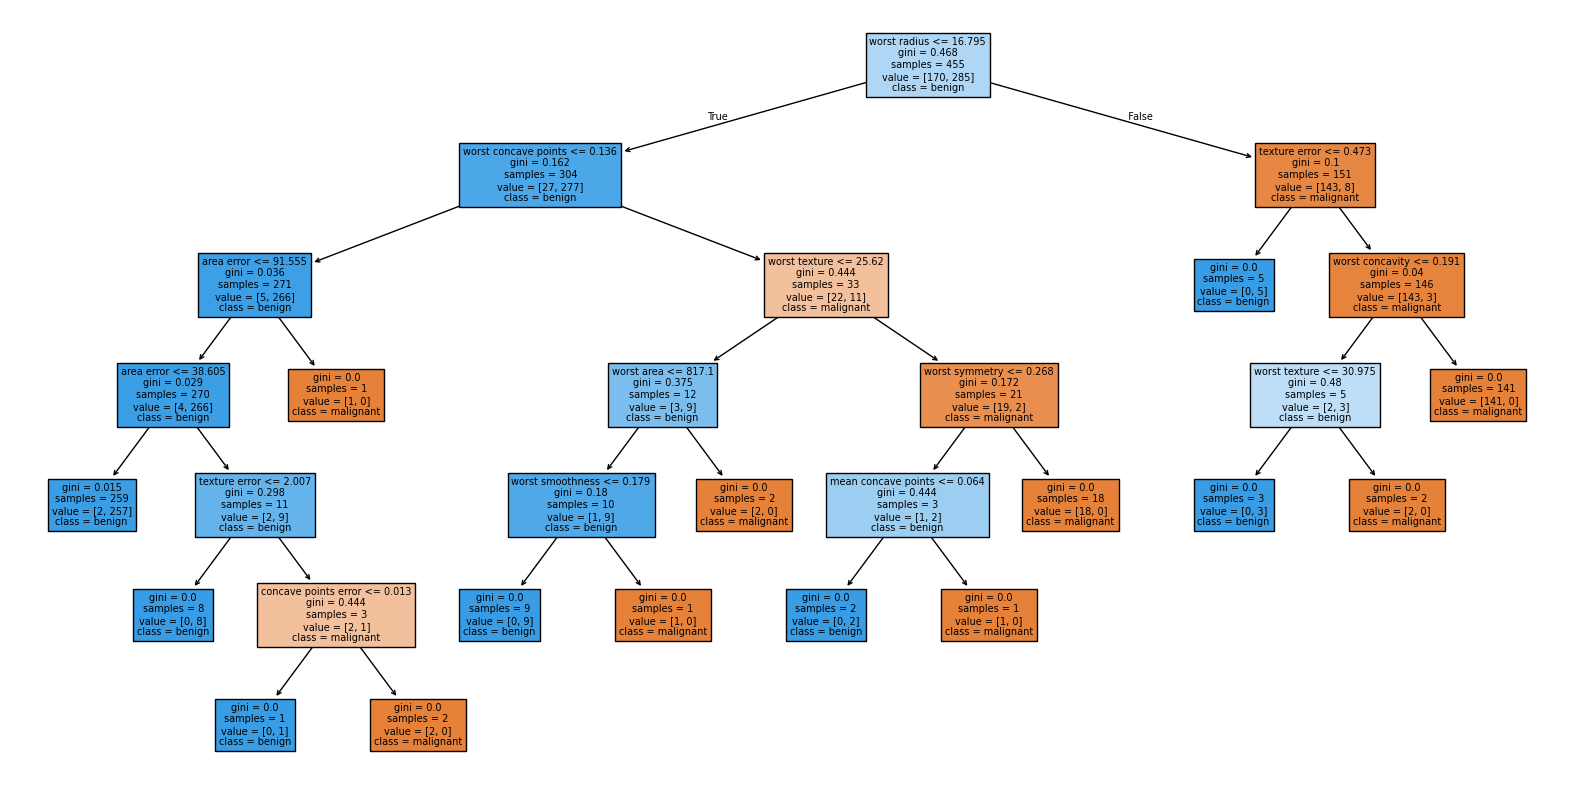

In [21]:
# 9. VISUALIZE FINAL TREE
# ==========================================

plt.figure(figsize=(20, 10))

plot_tree(
    final_tree,
    feature_names=X.columns,
    class_names=data.target_names,
    filled=True
)

plt.show()